# Text Classification using Pytorch for Tweets

### 1. Setup and Reproducibility

This section handles the initial setup for the project, including installing necessary libraries, importing them, and setting up random seeds for reproducibility. Reproducibility is crucial in machine learning to ensure that experiments can be replicated and results are consistent across different runs.

In [1]:
!pip install pandas numpy matplotlib seaborn torch scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [3]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 2. Data Loading and Initial Exploration

Here, we load the `train.csv` and `test.csv` datasets, which contain tweet data. We'll then perform an initial check of their dimensions and display the first few rows of the training data to understand its structure.

In [8]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.shape)
print(test_df.shape)
train_df.head()

(7613, 5)
(3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### 3. Word Cloud Generation (Before Cleaning)

This section sets up `nltk` for stopwords and `wordcloud` to visualize the most frequent words in tweets. We will generate separate word clouds for disaster and non-disaster tweets to get an initial understanding of the common vocabulary before any text cleaning.

In [9]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 4. Text Cleaning Function

Before tokenizing and feeding text to a model, it's essential to clean it. This `clean_text` function is designed to remove URLs, Twitter-specific content (mentions, hashtags, retweets), HTML tags, encoding errors, special characters, digits, and extra whitespace. This helps reduce noise and improves the quality of the text data.

In [11]:
def create_wordcloud(text_series, title):
    text = ' '.join(text_series)

    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=stop_words,
                          max_words=150,
                          collocations=False).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

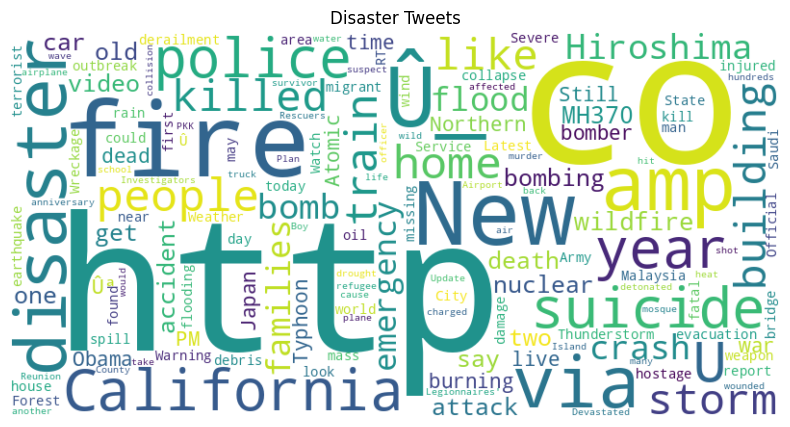

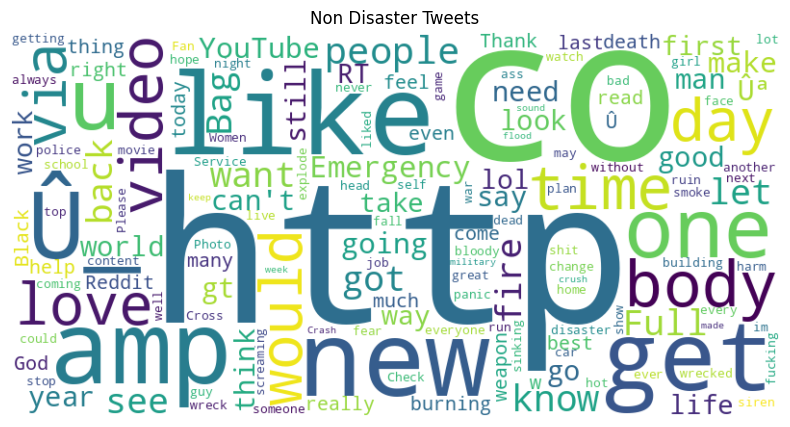

In [12]:
create_wordcloud(train_df[train_df['target'] == 1]['text'], 'Disaster Tweets')
create_wordcloud(train_df[train_df['target'] == 0]['text'], 'Non Disaster Tweets')

Clean words that are specific to tweets or scrapping like http, amp(&) etc.

In [13]:
def clean_text(text):

  text = text.lower()
  text = re.sub(r'https?://\S+|www\.\S+', '', text)

  # Remove Twitter-specific content
  text = re.sub(r'@\w+', '', text)  # Remove mentions
  text = re.sub(r'#', '', text)     # Remove hashtag symbols but keep the words
  text = re.sub(r'rt\s+', '', text)  # Remove RT (retweet) indicators
  text = re.sub(r'&\w+;', '', text)

  # Remove HTML tags
  text = re.sub(r'<.*?>', '', text)

  # Handle encoding errors like 'Û'
  text = re.sub(r'Û', '', text)

  # Remove special characters and digits
  text = re.sub(r'[^\w\s]', '', text)
  text = re.sub(r'\d+', '', text)

  # Remove extra whitespace
  text = re.sub(r'\s+', ' ', text).strip()

  return text

### 5. Applying Text Cleaning and Word Clouds (After Cleaning)

After defining the `clean_text` function, we apply it to both the training and test datasets. Subsequently, we regenerate word clouds for both disaster and non-disaster tweets to visually assess the impact of the cleaning process on the most frequent words.

In [14]:
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

### 6. Tokenization with DistilBERT

This section focuses on preparing the text data for a DistilBERT model. We install the `transformers` library and initialize `DistilBertTokenizer`. A custom `tokenize_text` function is created to convert the cleaned text into numerical input IDs and attention masks, which are required by the BERT-like models.

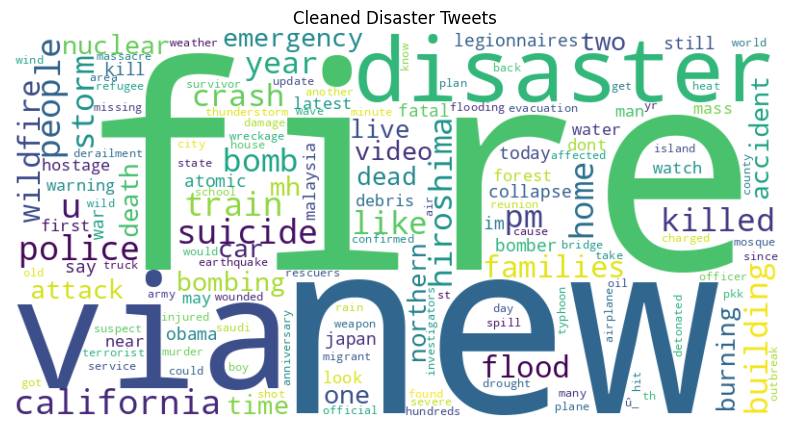

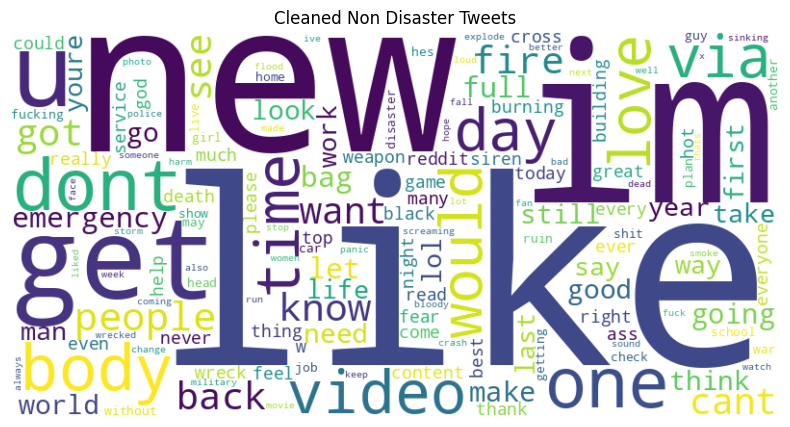

In [15]:
create_wordcloud(train_df[train_df['target'] == 1]['clean_text'], 'Cleaned Disaster Tweets')
create_wordcloud(train_df[train_df['target'] == 0]['clean_text'], 'Cleaned Non Disaster Tweets')

In [16]:
# !pip install transformers
from transformers import DistilBertTokenizer

In [17]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

example_text = "PyTorch is great for NLP"
tokens = tokenizer.tokenize(example_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(tokens)
print(token_ids)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['p', '##yt', '##or', '##ch', 'is', 'great', 'for', 'nl', '##p']
[1052, 22123, 2953, 2818, 2003, 2307, 2005, 17953, 2361]


In [20]:
def tokenize_text(text, tokenizer, max_length=128):
    encodings = tokenizer(
        list(text),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    return encodings['input_ids'], encodings['attention_mask']

### 7. Data Splitting and DataLoader Preparation

Here, the training data is split into training and validation sets using `train_test_split` with stratification to maintain the class distribution. The tokenized data and targets are then converted into `TensorDataset` and `DataLoader` objects, which are essential for efficient batching and feeding data to the PyTorch model during training and evaluation.

In [24]:
input_ids, attention = tokenize_text(example_text, tokenizer, 8)
print(input_ids)
print(attention)

tensor([[ 101, 1052,  102,    0,    0,    0,    0,    0],
        [ 101, 1061,  102,    0,    0,    0,    0,    0],
        [ 101, 1056,  102,    0,    0,    0,    0,    0],
        [ 101, 1051,  102,    0,    0,    0,    0,    0],
        [ 101, 1054,  102,    0,    0,    0,    0,    0],
        [ 101, 1039,  102,    0,    0,    0,    0,    0],
        [ 101, 1044,  102,    0,    0,    0,    0,    0],
        [ 101,  102,    0,    0,    0,    0,    0,    0],
        [ 101, 1045,  102,    0,    0,    0,    0,    0],
        [ 101, 1055,  102,    0,    0,    0,    0,    0],
        [ 101,  102,    0,    0,    0,    0,    0,    0],
        [ 101, 1043,  102,    0,    0,    0,    0,    0],
        [ 101, 1054,  102,    0,    0,    0,    0,    0],
        [ 101, 1041,  102,    0,    0,    0,    0,    0],
        [ 101, 1037,  102,    0,    0,    0,    0,    0],
        [ 101, 1056,  102,    0,    0,    0,    0,    0],
        [ 101,  102,    0,    0,    0,    0,    0,    0],
        [ 101,

In [28]:
train_texts, val_texts, train_targets, val_targets = train_test_split(
  train_df['clean_text'].values,
  train_df['target'].values,
  test_size=0.1,
  random_state=42,
  stratify=train_df['target']
)

print(f"Training texts: {len(train_texts)}")
print(f"Validation texts: {len(val_texts)}")

batch_size = 128

train_input_ids, train_attention = tokenize_text(train_texts, tokenizer, 128)
val_input_ids, val_attention = tokenize_text(val_texts, tokenizer, 128)

train_targets = torch.tensor(train_targets, dtype=torch.long)
val_targets = torch.tensor(val_targets, dtype=torch.long)

train_dataset = TensorDataset(train_input_ids, train_attention, train_targets)
val_dataset = TensorDataset(val_input_ids, val_attention, val_targets)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

batch = next(iter(train_loader))
input_ids, attention_mask, targets = batch

print(f"Input IDs shape: {input_ids.shape}")
print(f"Attention mask shape: {attention_mask.shape}")
print(f"Targets shape: {targets.shape}")

Training texts: 6851
Validation texts: 762
Input IDs shape: torch.Size([128, 128])
Attention mask shape: torch.Size([128, 128])
Targets shape: torch.Size([128])


### 8. Model Loading

In this step, we load a pre-trained `DistilBertForSequenceClassification` model from the `transformers` library. This model is fine-tuned for sequence classification tasks, and we specify `num_labels=2` for our binary classification problem (disaster vs. non-disaster). The model is then moved to the appropriate device (GPU if available, otherwise CPU).

In [29]:
from transformers import DistilBertForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
    ).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 9. Training and Evaluation Functions

This section defines two key functions: `train_epoch` and `evaluate`.

*   `train_epoch`: This function performs one pass over the training data, computes the loss, performs backpropagation, and updates model weights. It returns the average training loss and accuracy for the epoch.
*   `evaluate`: This function assesses the model's performance on a given dataset (typically validation or test). It calculates the average loss, accuracy, and F1-score without updating model weights. It also collects true labels and predictions for detailed metric calculation.

In [33]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    for batch in dataloader:
        input_ids, attention_mask, targets = batch
        input_ids, attention_mask, targets = input_ids.to(device), attention_mask.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=targets)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        total_predictions += len(targets)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions.double() / total_predictions

    return avg_loss, accuracy

In [36]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, targets = batch
            input_ids, attention_mask, targets = input_ids.to(device), attention_mask.to(device), targets.to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=targets)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == targets)
            total_predictions += len(targets)

            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions.double() / total_predictions
    f1 = f1_score(all_targets, all_preds)

    return avg_loss, accuracy, f1

### 10. Model Training Loop

This loop orchestrates the training process over a specified number of epochs. In each epoch, the model is trained using the `train_epoch` function and then evaluated on the validation set using the `evaluate` function. The F1-score on the validation set is used to track the best-performing model, which is then saved to disk.

In [37]:
epochs = 3
best_f1 = 0

for epoch in range(epochs):
  print(f"Epoch {epoch + 1}/{epochs}")
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, device)
  print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

  val_loss, val_acc, val_f1 = evaluate(model, val_loader, device)
  print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

  if val_f1 > best_f1:
    best_f1 = val_f1
    torch.save(model.state_dict(), 'best_model.pt')
    print("Saved best model")


Epoch 1/3
Train Loss: 0.3651, Train Acc: 0.8516
Val Loss: 0.3852, Val Acc: 0.8451, Val F1: 0.8162
Saved best model
Epoch 2/3
Train Loss: 0.3181, Train Acc: 0.8771
Val Loss: 0.4105, Val Acc: 0.8294, Val F1: 0.8024
Epoch 3/3
Train Loss: 0.2647, Train Acc: 0.9003
Val Loss: 0.4362, Val Acc: 0.8255, Val F1: 0.7982


### 11. Final Validation Set Evaluation

After the training loop completes, this section performs a detailed evaluation of the best-performing model on the validation set. It generates a comprehensive classification report, including precision, recall, and F1-score for each class, and visualizes the model's performance with a confusion matrix. This provides a deeper understanding of where the model is performing well and where it might be struggling.

              precision    recall  f1-score   support

Not Disaster       0.85      0.84      0.85       435
    Disaster       0.79      0.80      0.80       327

    accuracy                           0.83       762
   macro avg       0.82      0.82      0.82       762
weighted avg       0.83      0.83      0.83       762



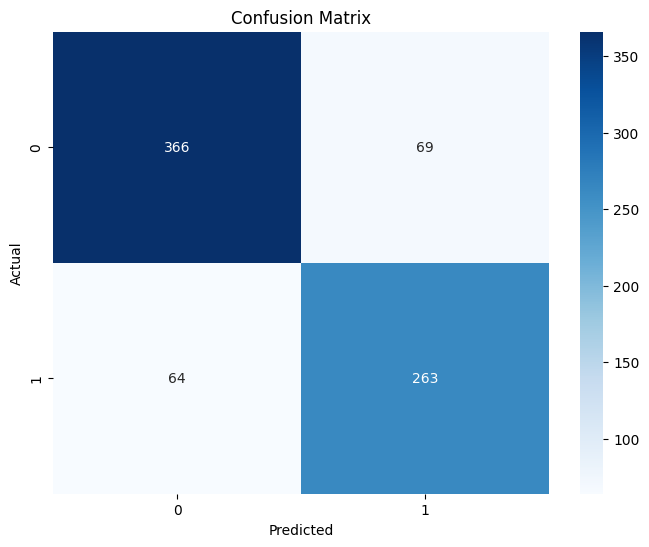

In [38]:
model.eval()
all_targets = []
all_preds = []
all_probs = []  # For prediction probabilities

with torch.no_grad():
    for batch in val_loader:

        input_ids, attention_mask, targets = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        targets = targets.to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = F.softmax(logits, dim=1)

        # Get predictions
        _, preds = torch.max(logits, dim=1)

        # Store targets, predictions, and probabilities
        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # For positive class

# Classification report
print(classification_report(all_targets, all_preds, target_names=['Not Disaster', 'Disaster']))

# Confusion matrix
cm = pd.crosstab(
    pd.Series(all_targets, name='Actual'),
    pd.Series(all_preds, name='Predicted')
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### 12. Test Set Prediction

Finally, the trained model is used to make predictions on the unseen `test.csv` dataset. The `test_df` is tokenized, a `DataLoader` is created, and the model generates predictions and associated probabilities. These predictions are then added back to the `test_df` for further analysis, and a sample of the results is displayed.

In [40]:
test_input_ids, test_attention_masks = tokenize_text(test_df['clean_text'].values, tokenizer)

# Create test dataloader
test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Generate predictions
model.eval()
test_preds = []
test_probs = []

with torch.no_grad():
    for batch in test_loader:
        # Unpack and move batch to device
        input_ids, attention_mask = batch
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = F.softmax(logits, dim=1)

        # Get predictions
        _, preds = torch.max(logits, dim=1)

        # Store predictions and probabilities
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs[:, 1].cpu().numpy())

# Add predictions to test dataframe
test_df['predicted_target'] = test_preds
test_df['disaster_probability'] = test_probs

# Display a sample of predictions
print("Sample predictions on the test set:")
sample_results = test_df[['text', 'predicted_target', 'disaster_probability']].sample(10)
sample_results

Sample predictions on the test set:


,text,predicted_target,disaster_probability
2406,Refugees as citizens - The Hindu http://t.co/G...,1,0.678501
134,@5SOStag honestly he could say an apocalypse i...,0,0.083926
411,If you bored as shit don't nobody fuck wit you...,0,0.031412
203,@RealTwanBrown Yesterday I Had A Heat Attack ?...,1,0.577876
889,The Devil Wears Prada is still one of my favou...,0,0.049691
1432,my father fucking died when the north tower co...,0,0.104361
3024,Oh itÛªs a soccer ball? I thought it was the ...,0,0.102930
2741,#Bestnaijamade: 16yr old PKK suicide bomber wh...,0,0.044699
463,@ComplexMag he asking for a body bags @PUSHA_T,0,0.046380
291,@JuneSnowpaw Yeah Gimme dat creamy white stuff ;3,0,0.042315
